# A practical OTICA tutorial

This notebook generates independent non-Gaussian sources, mixes them linearly, and recovers the sources with `OTICA`. The fitted components are matched to the true sources using the best absolute correlations.

OTICA is described in [Contrast-Free ICA and Causal Inference via Wasserstein Distances to the Gaussian](https://arxiv.org/abs/2607.12832).

In [1]:
# Imports
import matplotlib.pyplot as plt
import numpy as np

from otica import OTICA
from otica.utils import amari_index

## Generate independent sources

The three latent signals have different non-Gaussian distributions. Their scales are normalized so that each source has unit variance before mixing.

In [2]:
# Generate independent source signals.
rng = np.random.default_rng(42)
n_samples = 5_000
time = np.linspace(0.0, 8.0, n_samples)

sources = np.column_stack(
    [
        rng.laplace(size=n_samples) / np.sqrt(2.0),
        rng.uniform(-np.sqrt(3.0), np.sqrt(3.0), size=n_samples),
        rng.standard_t(df=5, size=n_samples) * np.sqrt(3.0 / 5.0),
    ]
)
sources.shape

(5000, 3)

## Mix and recover the sources

The observed signals are linear mixtures of the latent sources. `OTICA` centers and whitens the observations, then optimizes the Wasserstein non-Gaussianity objective on the orthogonal group.

In [3]:
# Mix observations and fit OTICA.
mixing = np.array(
    [
        [1.0, 0.5, -0.2],
        [0.2, 1.0, 0.4],
        [-0.4, 0.1, 1.0],
    ]
)
X = sources @ mixing.T

model = OTICA(random_state=42)
estimated_sources = model.fit_transform(X)
print("Estimated sources shape:", estimated_sources.shape)

Estimated sources shape: (5000, 3)


## Resolve ICA ambiguities

ICA identifies components up to permutation and sign. For each true source, select the estimated component with the largest absolute correlation and orient it with the same sign.

In [4]:
# Align permutation and sign ambiguities.
correlations = np.corrcoef(sources.T, estimated_sources.T)[:3, 3:]
best_indices = np.abs(correlations).argmax(axis=1)
best_correlations = correlations[np.arange(3), best_indices]
recovered_sources = estimated_sources[:, best_indices] * np.sign(best_correlations)

print("Best absolute correlation per source:", np.round(np.abs(best_correlations), 3))

Best absolute correlation per source: [1. 1. 1.]


## Evaluate source recovery

The Amari index evaluates the estimated unmixing matrix against the known mixing matrix. It is invariant to the permutation and scaling ambiguities of ICA, and zero indicates exact recovery up to those ambiguities.

In [5]:
# Compute the Amari index.
score = amari_index(mixing, model.components_)
print("Amari index:", score)

Amari index: 0.009519739738798716


## Compare true and recovered signals

The plot uses the OTICA palette: Gaussian-reference blue for the true sources and transport coral for the recovered sources.

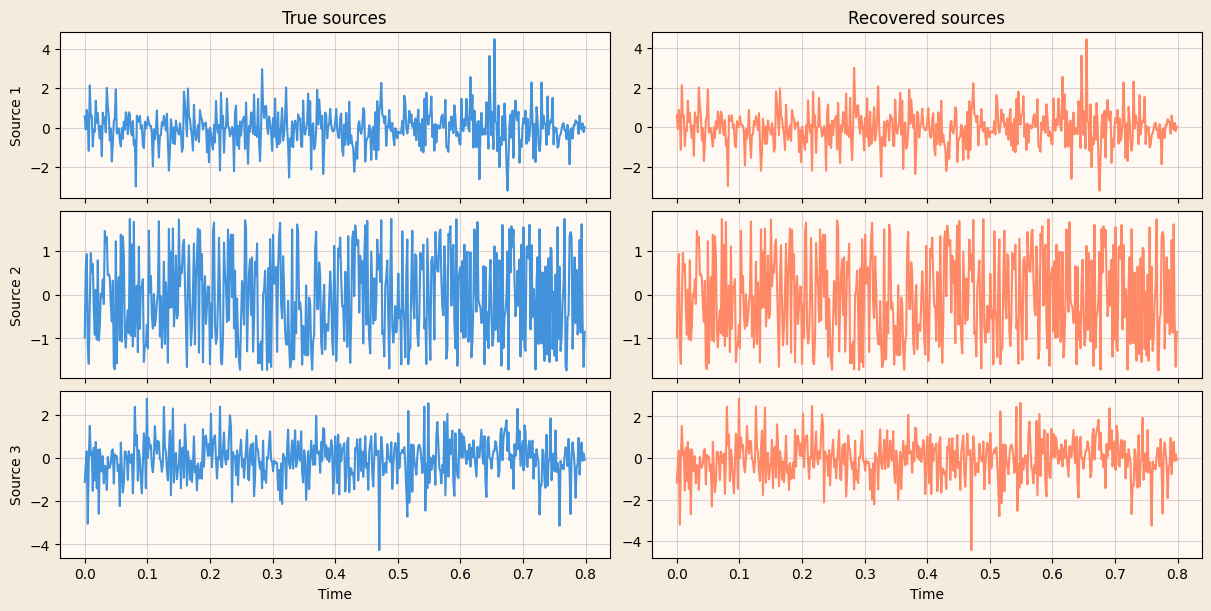

In [6]:
# Compare the first 500 samples.
fig, axes = plt.subplots(3, 2, sharex=True, figsize=(12, 6), layout="constrained")
fig.patch.set_facecolor("#F5EBDD")
for component in range(3):
    axes[component, 0].plot(time[:500], sources[:500, component], color="#4292DC")
    axes[component, 1].plot(time[:500], recovered_sources[:500, component], color="#FF8866")
    axes[component, 0].set_ylabel(f"Source {component + 1}")
    for ax in axes[component]:
        ax.set_facecolor("#FFF9F3")
        ax.grid(alpha=0.2, color="#573650")

axes[0, 0].set_title("True sources")
axes[0, 1].set_title("Recovered sources")
axes[-1, 0].set_xlabel("Time")
axes[-1, 1].set_xlabel("Time")
plt.show()

## Inspect the fitted estimator

The fitted estimator follows the scikit-learn transformer API. Use `transform` for source estimates and `inverse_transform` to map components back to the observation space.

In [7]:
# Inspect learned matrices and reconstruction.
print("Components:", model.components_.shape)
print("Mixing matrix:", model.mixing_.shape)
print("Reconstruction error:", np.max(np.abs(model.inverse_transform(estimated_sources) - X)))

Components: (3, 3)
Mixing matrix: (3, 3)
Reconstruction error: 4.884981308350689e-15
